# Weather forecast tool calling

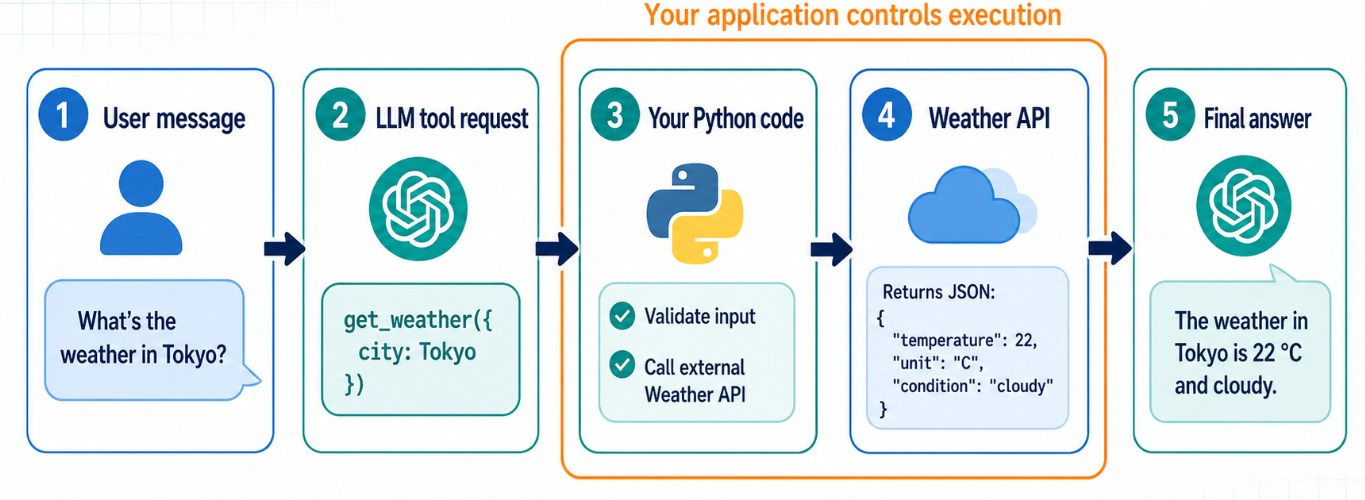

In [ ]:
from openai import OpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pydantic_settings import BaseSettings
import requests
import json

# Load environment variables, including OPENAI_API_KEY.
load_dotenv()

# Store configurable application settings.
class ModelSettings(BaseSettings):
    model_name:str =Field(default="gpt-4o-mini")

# 1. Advertise an application tool to the model.
# This schema does NOT execute get_weather().
# It tells the LLM when the tool is appropriate and what arguments it accepts.
tools = [{
           "type":"function",
            # function name as informative to LLM that get_weather function is available 
            # incase if any weather forecast require is made.
           "name":"get_weather", 
           "description": "Get weather for a requested city.",
           "parameters":{
               "type": "object",
               "properties":{
                   "city":{
                       "type":"string",
                       "description":"City name, e.g. 'Tokyo' or 'San Francisco'",
                   },
               },
               "required":["city"]
           },
         },
        ]

# 2. Implement the tool in application code.
# This function, not the LLM, contacts the external weather service.
def get_weather(city:str):

     # Convert the city name into latitude and longitude.
    geo_response = requests.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={"name":city},
        timeout=10
    )
    results = geo_response.json().get("results", [])
    if not results:
        return {"error": f"Location not found: {city}"}
    location = results[0]

     # Use the coordinates to retrieve current weather.
    weather_response = requests.get(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": location["latitude"],
            "longitude": location["longitude"],
            "current": "temperature_2m,apparent_temperature,weather_code",
            "timezone": "auto",
        },
        timeout=10,
    )
    weather_response.raise_for_status()

    # Return structured data for the model to interpret.
    current = weather_response.json()["current"]
    print(current)
    return {
        "city": location["name"],
        "temperature_c": current["temperature_2m"],
        "feels_like_c": current["apparent_temperature"],
        "weather_code": current["weather_code"],
        "observed_at": current["time"],
    }


client = OpenAI()

input_text=[
            {
                "role":"user",
                "content":"What's the weather in Tokyo?"
            }
        ]

# 3. Send the user message and available tool schemas to the model.
# The LLM uses natural-language understanding to interpret the user's intent.
#
# Weather-related inputs:
# - "What's the weather in Tokyo?"
# - "How's the weather in Tokyo?"
#
# Because get_weather is an available, relevant tool, the model can request:
# get_weather({"city": "Tokyo"})
#
# Unrelated input:
# - "What's the hotel availability in Tokyo?"
#
# No hotel tool is available, so the model should not request get_weather.
# It should respond normally, explaining that it cannot check hotel availability.
response = client.responses.create(
                model=ModelSettings().model_name,
                tools=tools,
                input=input_text
            )

# 4. Preserve the model's function-call request in conversation history.
# The next model call needs this to associate the result with its request.
input_text += response.output
# 5. Inspect each model output item.
# Only application code decides whether to execute a requested function.
for item in response.output:
    print(item)
    if item.type != "function_call":
        continue

    arguments = json.loads(item.arguments)
    weather = get_weather(arguments["city"])
    input_text.append(
       {
            "type":"function_call_output",
            "call_id":item.call_id,
            "output":json.dumps(weather)
        }
    )

# 7. Ask the model to use the tool result and create a final human-readable answer.
final_response = client.responses.create(
    model=ModelSettings().model_name,
    tools=tools,
    input=input_text,
)
print(final_response.output_text)

ResponseFunctionToolCall(arguments='{"city":"Tokyo"}', call_id='call_lIjjqjUoCe5R5UekP2tSSo3o', name='get_weather', type='function_call', id='fc_0cac35eac8436d3d006a8c3e65125487d18b8017b51d72010b', caller=None, namespace=None, status='completed')
{'time': '2026-08-24T21:45', 'interval': 900, 'temperature_2m': 26.1, 'apparent_temperature': 32.0, 'weather_code': 0}
ResponseFunctionToolCall(arguments='{"city":"Tokyo"}', call_id='call_uYiLXcbk6E2jx2mfY9pAb6fp', name='get_weather', type='function_call', id='fc_0cac35eac8436d3d006a8c3e65126887d1b85ee62d404ddc68', caller=None, namespace=None, status='completed')
{'time': '2026-08-24T21:45', 'interval': 900, 'temperature_2m': 26.1, 'apparent_temperature': 32.0, 'weather_code': 0}
### Weather in Tokyo
- **Temperature:** 26.1°C
- **Feels Like:** 32.0°C
- **Weather Condition:** Clear skies

### Attractions in Tokyo
1. **Tokyo Tower** - Iconic landmark with observation decks offering stunning views.
2. **Shibuya Crossing** - One of the busiest ped